# Kunci Jawaban - Linear Regression

- **Dataset:** Fish Market
- **Target:** `Weight`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan boxplot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE, boxplot, dan regression plot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Siapkan file dataset Kaggle

Download dataset dari Kaggle, lalu letakkan file `Fish.csv` di folder kerja notebook.

In [5]:
DATA_PATH = "Fish.csv"

### Baca dataset CSV

Baca file CSV menjadi DataFrame bernama `df`.

In [6]:
df = pd.read_csv(DATA_PATH)

### Tentukan kolom target

Tentukan kolom `Weight` sebagai target prediksi.

In [7]:
TARGET_COL = "Weight"

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom pada dataset.

In [8]:
df.shape

(159, 7)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki 159 baris dan 7 kolom.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat contoh isi data.

In [9]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.000,23.200,25.400,30.000,11.520,4.020
1,Bream,290.000,24.000,26.300,31.200,12.480,4.306
2,Bream,340.000,23.900,26.500,31.100,12.378,4.696
3,Bream,363.000,26.300,29.000,33.500,12.730,4.455
4,Bream,430.000,26.500,29.000,34.000,12.444,5.134


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Tidak semua kolom berisi angka karena ada kolom kategori.

> Kolom mana yang berisi kategori?

Jawaban: Kolom `Species` berisi kategori jenis ikan.

## 3 - Data Understanding

### Tampilkan informasi dataset

Tampilkan informasi struktur dataset menggunakan `info()`.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


> Berdasarkan output `info()`, apa tipe data setiap kolom?

Jawaban: `Species` bertipe `object`, sedangkan `Weight`, `Length1`, `Length2`, `Length3`, `Height`, dan `Width` bertipe `float64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak. Semua kolom memiliki 159 non-null, sama dengan jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [11]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris duplikat penuh pada dataset.

In [12]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah 0.

### Tampilkan statistik deskriptif

Tampilkan statistik deskriptif untuk kolom numerik dan kategori.

In [13]:
df.describe(include="all")

,Species,Weight,Length1,Length2,Length3,Height,Width
count,159,159.000,159.000,159.000,159.000,159.000,159.000
unique,7,NaN,NaN,NaN,NaN,NaN,NaN
top,Perch,NaN,NaN,NaN,NaN,NaN,NaN
freq,56,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,398.326,26.247,28.416,31.227,8.971,4.417
std,NaN,357.978,9.996,10.716,11.610,4.286,1.686
min,NaN,0.000,7.500,8.400,8.800,1.728,1.048
25%,NaN,120.000,19.050,21.000,23.150,5.945,3.386
50%,NaN,273.000,25.200,27.300,29.400,7.786,4.248
75%,NaN,650.000,32.700,35.500,39.650,12.366,5.585


> Berdasarkan statistik deskriptif, bagaimana perbedaan skala antar kolom numerik?

Jawaban: Skala `Weight` jauh lebih besar dibandingkan fitur ukuran seperti `Length1`, `Length2`, `Length3`, `Height`, dan `Width`.

> Berdasarkan statistik deskriptif, apa kategori yang paling sering muncul pada kolom `Species`?

Jawaban: Kategori yang paling sering muncul adalah `Perch`.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh agar data lebih bersih.

In [14]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index setelah proses cleaning.

In [15]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah proses cleaning.

In [16]:
df_clean.shape

(159, 7)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Ukuran dataset tetap 159 baris dan 7 kolom.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat penuh setelah cleaning.

In [17]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak ada baris duplikat setelah cleaning.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Tampilkan statistik deskriptif khusus untuk target `Weight`.

In [18]:
df_clean[TARGET_COL].describe()

count    159.000
mean     398.326
std      357.978
min        0.000
25%      120.000
50%      273.000
75%      650.000
max     1650.000
Name: Weight, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Mean target sekitar 398.326, minimum 0.000, dan maksimum 1650.000.

### Buat histogram target

Gunakan histogram dengan KDE untuk melihat distribusi target `Weight`.

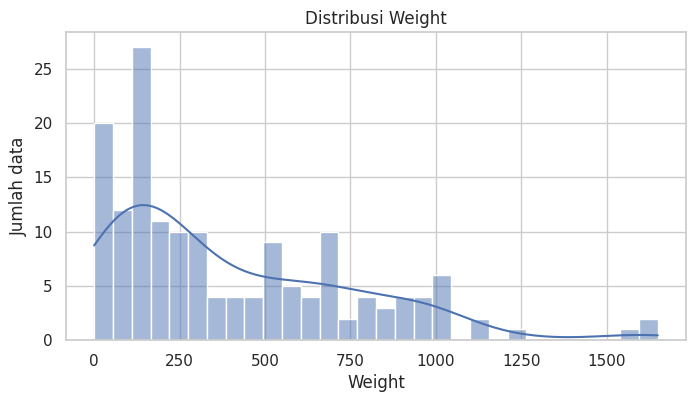

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi Weight")
plt.xlabel("Weight")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Nilai target paling banyak muncul pada rentang bobot rendah, terutama sekitar 110 sampai 165.

> Apakah distribusi target terlihat simetris atau cenderung miring?

Jawaban: Distribusi target cenderung miring ke kanan karena masih ada ikan dengan bobot jauh lebih besar.

### Hitung korelasi fitur numerik dengan target

Hitung korelasi fitur numerik terhadap target `Weight`.

In [20]:
numeric_corr = df_clean.select_dtypes(include="number").corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

Length3   0.923
Length2   0.919
Length1   0.916
Width     0.887
Height    0.724
Name: Weight, dtype: float64

> Berdasarkan output korelasi, fitur numerik apa yang memiliki korelasi positif paling tinggi terhadap target?

Jawaban: Fitur `Length3` memiliki korelasi positif paling tinggi terhadap target.

> Apakah semua fitur numerik memiliki korelasi positif terhadap target?

Jawaban: Ya. Semua fitur numerik memiliki korelasi positif terhadap `Weight`.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat kekuatan korelasi fitur numerik dengan target.

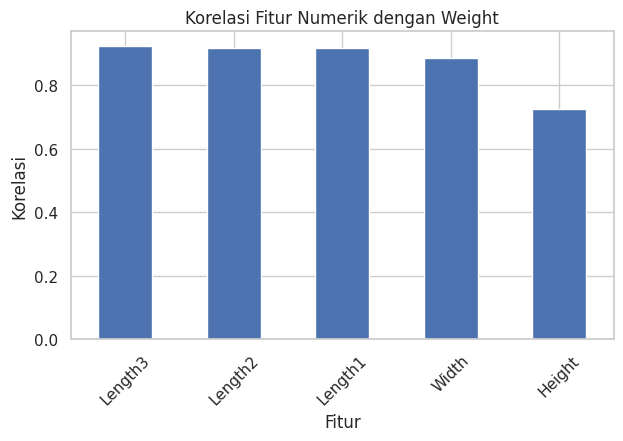

In [21]:
plt.figure(figsize=(7, 4))
numeric_corr.plot(kind="bar")
plt.title("Korelasi Fitur Numerik dengan Weight")
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.xticks(rotation=45)
plt.show()

> Berdasarkan bar plot, fitur numerik mana yang terlihat paling kuat hubungannya dengan target?

Jawaban: `Length3`, `Length2`, dan `Length1` terlihat paling kuat hubungannya dengan target.

### Buat boxplot Weight berdasarkan Species

Gunakan boxplot untuk membandingkan persebaran `Weight` pada setiap jenis ikan.

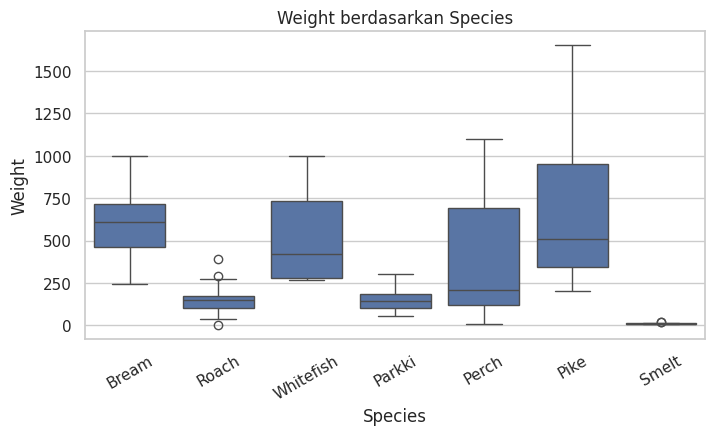

In [22]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x="Species", y=TARGET_COL)
plt.title("Weight berdasarkan Species")
plt.xlabel("Species")
plt.ylabel("Weight")
plt.xticks(rotation=30)
plt.show()

> Berdasarkan boxplot, species mana yang cenderung memiliki Weight lebih tinggi?

Jawaban: `Pike` dan `Bream` cenderung memiliki Weight lebih tinggi dibandingkan species lain.

> Mengapa boxplot lebih tepat daripada scatter plot untuk kolom `Species`?

Jawaban: Boxplot lebih tepat karena `Species` adalah kolom kategori, sehingga lebih cocok dibaca sebagai perbandingan kelompok.

### Buat scatter plot Length3 dan target

Gunakan scatter plot dengan garis regresi untuk melihat hubungan `Length3` dengan `Weight`.

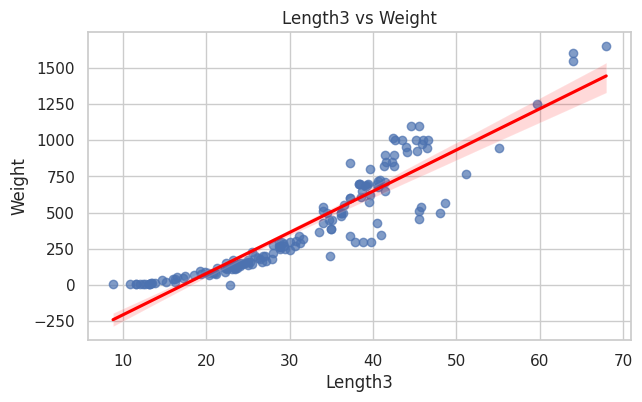

In [23]:
plt.figure(figsize=(7, 4))
sns.regplot(data=df_clean, x="Length3", y=TARGET_COL, scatter_kws={"alpha": 0.7}, line_kws={"color": "red"})
plt.title("Length3 vs Weight")
plt.xlabel("Length3")
plt.ylabel("Weight")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `Length3` dengan target?

Jawaban: Hubungan `Length3` dengan target terlihat positif; ikan yang lebih panjang cenderung memiliki bobot lebih besar.

> Apakah garis regresi membantu membaca arah hubungan pada plot ini?

Jawaban: Ya. Garis regresi membantu menunjukkan arah hubungan positif antara `Length3` dan `Weight`.

## 6 - Feature dan Target

### Pisahkan fitur awal

Pisahkan semua kolom selain target sebagai fitur awal.

In [24]:
X_raw_model = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke dalam variabel `y`.

In [25]:
y = df_clean[TARGET_COL]

### Encode fitur kategori

Ubah kolom kategori menjadi kolom numerik menggunakan `pd.get_dummies()`.

In [26]:
X = pd.get_dummies(X_raw_model, drop_first=True)

### Tampilkan ukuran fitur setelah encoding

Tampilkan ukuran `X` setelah kolom kategori diubah menjadi numerik.

In [27]:
X.shape

(159, 11)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X` setelah encoding?

Jawaban: `X` memiliki 159 baris dan 11 fitur setelah encoding.

### Tampilkan ukuran target

Tampilkan ukuran `y` sebagai target model.

In [28]:
y.shape

(159,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki 159 nilai target.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [29]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji sebanyak 20% dan data latih sebanyak 80%.

### Bagi data train dan test

Bagi fitur dan target menjadi data train dan data test.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Tampilkan ukuran fitur pada data train.

In [31]:
X_train.shape

(127, 11)

### Tampilkan ukuran X_test

Tampilkan ukuran fitur pada data test.

In [32]:
X_test.shape

(32, 11)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki 127 baris dan data test memiliki 32 baris.

## 8 - Feature Scaling

### Buat object scaler

Buat object `StandardScaler` untuk menyamakan skala fitur.

In [33]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler pada data train, lalu ubah data train ke skala standar.

In [34]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Ubah data test menggunakan scaler yang sudah di-fit pada data train.

In [35]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [36]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [37]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan?

Jawaban: Output menampilkan object `LinearRegression()`, yang berarti model berhasil dibuat dan dilatih.

### Tampilkan intercept model

Tampilkan nilai intercept dari model Linear Regression.

In [38]:
model.intercept_

np.float64(386.7944881889762)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar 386.794.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel.

In [39]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_table

,Feature,Coefficient
1,Length2,590.247
2,Length3,446.205
9,Species_Smelt,84.855
5,Species_Parkki,37.589
6,Species_Perch,36.053
8,Species_Roach,12.482
4,Width,11.765
10,Species_Whitefish,7.235
3,Height,-42.741
7,Species_Pike,-103.781


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Fitur `Length2` memiliki koefisien positif terbesar.

> Fitur mana yang memiliki koefisien negatif terbesar arahnya?

Jawaban: Fitur `Length1` memiliki koefisien negatif terbesar arahnya.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk membuat prediksi pada data train.

In [40]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk membuat prediksi pada data test.

In [41]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama pada data test.

In [42]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}).head()

prediction_preview

,Actual,Predicted
0,78.000,18.738
1,13.400,11.886
2,200.000,187.711
3,270.000,332.740
4,150.000,212.097


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dengan nilai aktual?

Jawaban: Baris kedua terlihat paling dekat karena actual 13.400 dan predicted sekitar 11.886.

> Prediksi mana yang terlihat paling jauh dari nilai aktual?

Jawaban: Baris kelima terlihat paling jauh karena actual 150.000 dan predicted sekitar 212.097.

### Hitung MAE train

Hitung MAE pada data train.

In [43]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

69.17284220611174

### Hitung MAE test

Hitung MAE pada data test.

In [44]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

65.300051533574

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar 65.300.

### Hitung RMSE train

Hitung RMSE pada data train.

In [45]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(93.6888722458669)

### Hitung RMSE test

Hitung RMSE pada data test.

In [46]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(83.71011402365906)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar 83.710.

### Hitung R2 train

Hitung R2 Score pada data train.

In [47]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.928595689771155

### Hitung R2 test

Hitung R2 Score pada data test.

In [48]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.9507352480054508

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar 0.951.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 Score untuk data train dan data test.

In [49]:
evaluation_table = pd.DataFrame({
    "Data": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2 Score": [r2_train, r2_test]
})

evaluation_table

,Data,MAE,RMSE,R2 Score
0,Train,69.173,93.689,0.929
1,Test,65.300,83.710,0.951


> Berdasarkan tabel evaluasi, bagaimana perbandingan MAE train dan MAE test?

Jawaban: MAE test sekitar 5.60% lebih rendah daripada MAE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan RMSE train dan RMSE test?

Jawaban: RMSE test sekitar 10.65% lebih rendah daripada RMSE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan R2 train dan R2 test?

Jawaban: R2 test sekitar 2.38% lebih tinggi daripada R2 train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk membandingkan nilai aktual dan prediksi pada data test.

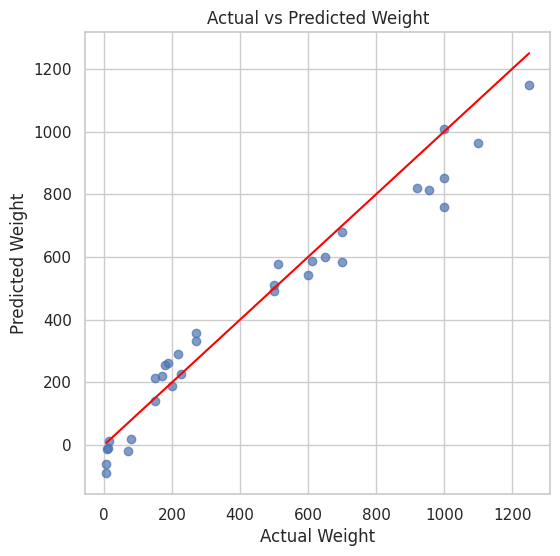

In [50]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted Weight")
plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")
plt.show()

## 11 - Kesimpulan

Dataset Fish Market digunakan untuk memprediksi `Weight` berdasarkan ukuran fisik ikan dan species ikan. Dataset memiliki 159 baris dan 7 kolom. Data tidak memiliki missing value dan memiliki 0 baris duplikat penuh.

EDA menunjukkan bahwa target `Weight` cenderung miring ke kanan. Fitur numerik yang paling kuat hubungannya dengan target adalah `Length3`, sedangkan kolom `Species` diubah menjadi numerik menggunakan `pd.get_dummies()`.

Data dibagi menjadi 80% data train dan 20% data test. Berdasarkan evaluasi, MAE test bernilai sekitar 65.300, RMSE test sekitar 83.710, dan R2 test sekitar 0.951.